# OpenSim Pendulum: Contact Handling

In this third tutorial on the OpenSim pendulum, we extend the model by adding contact geometry and a Hunt-Crossley contact force. The pendulum swings into a wall, and the contact model governs the collision response.

1. **[Basics](01_opensim_pendulum_basics.ipynb)**: We set up a single-link pendulum with a pin joint and simulate its free swing under gravity.
2. **[Torque Application](02_opensim_pendulum_torque.ipynb)**: We extend the model by applying an external torque via a `CoordinateActuator`.
3. **Contact Handling** (this tutorial): We further extend the model by adding contact geometry and forces.

```{figure} pendulum_contact.png
---
width: 60%
figclass: caption
alt: opensim-pendulum-fig-contact
name: opensim-pendulum-fig-contact
---
Pendulum model with contact geometry in the OpenSim visualizer.
```

## Overview

This tutorial adds a **contact interaction** between the pendulum head and a rigid wall positioned at the vertical of the pivot point. The contact is modeled using the **Hunt-Crossley** force law.

Core ideas:
1. Attach a `ContactSphere` to the pendulum head and a `ContactHalfSpace` to the base (representing a wall).
2. Create a `HuntCrossleyForce` that governs the normal contact force between the two geometries.
3. Simulate the pendulum swinging into the wall under gravity and an applied torque.
4. Investigate the influence of contact parameters (stiffness, dissipation) on the collision response.

## Learning Goals
- Understand the Hunt-Crossley contact force model and its parameters
- Set up `ContactSphere` and `ContactHalfSpace` geometries in OpenSim
- Configure a `HuntCrossleyForce` with stiffness and dissipation parameters
- Simulate contact events and observe energy dissipation during collisions
- Compare different contact parameter configurations in a parameter study

## Prerequisites and Setup

This notebook assumes you have completed [Tutorial 01 — Basics](01_opensim_pendulum_basics.ipynb) and [Tutorial 02 — Torque Application](02_opensim_pendulum_torque.ipynb) and are familiar with:
- Building OpenSim models with bodies, joints, and coordinates
- Using the `CoordinateActuator` with actuation override
- Running forward dynamics with the `Manager`

### Background — Hunt-Crossley Contact Model

The classical linear spring-dashpot (Kelvin-Voigt) contact model $F = kx + c\dot{x}$ has a well-known deficiency: the damping force is maximal at the instant of first contact ($x=0$, $\dot{x}=v_i$), which produces an unphysical tensile force at separation and incorrect energy scaling.

Hunt and Crossley (1975) proposed a modified force law where the damping coefficient depends on the penetration depth $x$:

$$F = k\,x^n\bigl(1 + \tfrac{3}{2}\,\alpha\,\dot{x}\bigr)$$

where:
- $k$ is the contact **stiffness** (units depend on $n$),
- $n$ is the force-displacement exponent ($n = 3/2$ for Hertzian contact),
- $\alpha$ is a material-dependent **dissipation** coefficient (units: s/m),
- $\dot{x}$ is the penetration rate (negative during approach).

**Key properties:**
- The contact force is **zero at first contact** ($x = 0$) — no instantaneous force spike.
- The damping force vanishes at maximum compression ($\dot{x} = 0$) and at separation ($x = 0$).
- The energy loss scales as $\Delta E \propto v_i^3$, consistent with experimental observations.
- The coefficient of restitution is related to $\alpha$ via $e \approx 1 - \alpha\,v_i$ for small dissipation.

In OpenSim, the `HuntCrossleyForce` uses $n = 3/2$ (Hertzian) and parameterizes the model with:
- `stiffness` $k$: contact stiffness in N/m
- `dissipation` $\alpha$: dissipation coefficient in s/m (higher values → more energy loss per collision)
- Optional friction coefficients (static, dynamic, viscous)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opensim as osim

## Model Parameters

We use the same pendulum parameters as in tutorials 01 and 02. The contact parameters are defined separately.

In [2]:
mass = 40.0          # mass of the pendulum head [kg]
r_head = 0.05        # radius of the pendulum head [m]
length = 0.5         # length of the pendulum rod [m]
inertia_head = 20.0  # moment of inertia of the head about Z-axis [kg·m²]
g_val = 9.81         # gravitational acceleration [m/s²]

## Building the OpenSim Model With Contact

We encapsulate the full model construction (pendulum + actuator + contact) in a reusable function. The contact geometry and force are the key additions compared to tutorials 01 and 02.

In [3]:
def build_pendulum_with_contact(contact_params, use_gravity=True):
    """Build an OpenSim pendulum model with contact geometry and a Hunt-Crossley force.
    
    Parameters
    ----------
    contact_params : dict
        Keys: 'stiffness', 'dissipation', 'static_friction', 'dynamic_friction', 'viscous_friction'.
    use_gravity : bool
        Whether to enable gravity.
        
    Returns
    -------
    model, coord, actuator : osim.Model, osim.Coordinate, osim.CoordinateActuator
    """
    model = osim.Model()
    model.setName('Pendulum')
    model.setGravity(osim.Vec3(0, -g_val if use_gravity else 0, 0))

    ground = model.getGround()

    # --- Base body (fixed pivot) ---
    base = osim.Body("pendulum_base", 1.0, osim.Vec3(0), osim.Inertia(0, 0, 0))
    base_geom = osim.Brick(osim.Vec3(0.1, 0.01, 0.1))
    base_geom.setColor(osim.Vec3(0.8, 0.2, 0.2))
    base.attachGeometry(base_geom)
    model.addBody(base)

    base_to_ground = osim.WeldJoint(
        "base_to_ground",
        ground, osim.Vec3(0, 1.2 * length, 0), osim.Vec3(0),
        base, osim.Vec3(0), osim.Vec3(0),
    )
    model.addJoint(base_to_ground)

    # --- Pendulum head body ---
    head = osim.Body("pendulum_head", mass, osim.Vec3(0), osim.Inertia(0, 0, inertia_head))
    head_geom = osim.Sphere(r_head)
    head_geom.setColor(osim.Vec3(0.2, 0.2, 0.8))
    head.attachGeometry(head_geom)
    model.addBody(head)

    head_to_base = osim.PinJoint(
        "head_to_base",
        base, osim.Vec3(0), osim.Vec3(0),
        head, osim.Vec3(0, length, 0), osim.Vec3(0),
    )
    model.addJoint(head_to_base)

    # --- Rod visualization ---
    head_of = osim.PhysicalOffsetFrame()
    head_of.setName("head_of")
    head_of.setParentFrame(head)
    head_of.set_translation(osim.Vec3(0, length / 2, 0))
    head_of_geom = osim.Cylinder(r_head / 4, length / 2)
    head_of_geom.setColor(osim.Vec3(0.2, 0.8, 0.2))
    head_of.attachGeometry(head_of_geom)
    head.addComponent(head_of)

    # --- Coordinate ---
    coord = head_to_base.getCoordinate()
    coord.setName("theta")

    # --- CoordinateActuator ---
    actuator = osim.CoordinateActuator()
    actuator.setName("torque")
    actuator.setCoordinate(coord)
    actuator.setOptimalForce(1)
    actuator.setMinControl(-1e6)
    actuator.setMaxControl(1e6)
    model.addForce(actuator)

    # --- Contact Geometry ---
    # Contact sphere on the pendulum head
    cs = osim.ContactSphere()
    cs.setName("head_contact")
    cs.setRadius(r_head)
    cs.connectSocket_frame(head)
    model.addContactGeometry(cs)

    # Contact half-space (wall) attached to the base
    # Positioned so impact occurs near θ = 0 when the pendulum swings to the left (ω < 0)
    wall = osim.ContactHalfSpace()
    wall.setName("wall_contact")
    wall.connectSocket_frame(base)
    wall.setOrientation(osim.Vec3(0, np.pi, 0))
    wall.setLocation(osim.Vec3(-r_head, 0, 0))
    model.addContactGeometry(wall)

    # --- Hunt-Crossley Contact Force ---
    hcf = osim.HuntCrossleyForce()
    hcf.addGeometry("wall_contact")
    hcf.addGeometry("head_contact")
    hcf.setName("contact_force")
    hcf.setStiffness(contact_params["stiffness"])
    hcf.setDissipation(contact_params["dissipation"])
    hcf.setStaticFriction(contact_params.get("static_friction", 0.0))
    hcf.setDynamicFriction(contact_params.get("dynamic_friction", 0.0))
    hcf.setViscousFriction(contact_params.get("viscous_friction", 0.0))
    model.addForce(hcf)

    model.finalizeConnections()

    return model, coord, actuator

### Contact Geometry Setup

The contact setup consists of two elements:

| Geometry | Type | Attached to | Purpose |
|----------|------|-------------|---------|
| `head_contact` | `ContactSphere` | Pendulum head body | Spherical contact surface on the bob |
| `wall_contact` | `ContactHalfSpace` | Base body | Infinite rigid wall at the vertical |

The `ContactHalfSpace` is oriented and positioned so that the wall is located at the vertical line through the pivot ($\theta = 0$). The pendulum head collides with this wall when swinging past the vertical.

The `HuntCrossleyForce` monitors the penetration between the two contact geometries and applies the Hunt-Crossley force law whenever overlap is detected.

## Simulation Helper

We reuse the simulation loop from Tutorial 02, extended to handle contact. The torque can be a function of time or a constant.

In [4]:
def simulate_contact_pendulum(model, coord, actuator, torque_func,
                              q0=0.0, omega0=0.0, dt=0.001, t_end=5.0):
    """Run a forward dynamics simulation with contact.
    
    Parameters
    ----------
    model : osim.Model
    coord : osim.Coordinate
    actuator : osim.CoordinateActuator
    torque_func : callable
        Function torque_func(t) -> float returning the torque in N·m.
    q0 : float
        Initial angle [rad].
    omega0 : float
        Initial angular velocity [rad/s].
    dt : float
        Reporting interval [s].
    t_end : float
        End time [s].
        
    Returns
    -------
    dict with keys 'time', 'theta', 'omega', 'alpha'.
    """
    coord.setDefaultValue(q0)
    coord.setDefaultSpeedValue(omega0)

    state = model.initSystem()

    actuator.overrideActuation(state, True)
    actuator.setOverrideActuation(state, torque_func(0.0))
    model.realizeAcceleration(state)

    manager = osim.Manager(model)
    manager.initialize(state)

    t_vals, theta_vals, omega_vals, alpha_vals = [], [], [], []

    t = 0.0
    while t < t_end - 1e-8:
        actuator.setOverrideActuation(state, torque_func(t))

        state = manager.integrate(t + dt)
        model.realizeAcceleration(state)

        t_vals.append(state.getTime())
        theta_vals.append(coord.getValue(state))
        omega_vals.append(coord.getSpeedValue(state))
        alpha_vals.append(coord.getAccelerationValue(state))

        t = state.getTime()

    return {
        'time': np.array(t_vals),
        'theta': np.array(theta_vals),
        'omega': np.array(omega_vals),
        'alpha': np.array(alpha_vals),
        'manager': manager,
        'model': model,
    }

## Simulation Parameters

In [5]:
q0 = np.deg2rad(45)    # initial angle [rad]
omega0 = 0.0            # initial angular velocity [rad/s]
dt = 0.0001             # reporting interval [s] (small for contact resolution)
t_end = 5.0             # end time [s]
Mz = 0.0                # no applied torque — free swing into wall

## Free Swing Into a Wall

We first simulate the pendulum swinging freely under gravity with no applied torque. Starting from $\theta_0 = 45°$, the pendulum swings through the vertical and impacts the wall near $\theta = 0$.

### Default Contact Parameters

We use moderate contact parameters as a baseline:
- **Stiffness** $k = 10^{6}$ N/m $: stiff enough for a clear bounce, soft enough for numerical stability.
- **Dissipation** $\alpha = 0.5$ s/m: noticeable energy loss per collision.

In [6]:
default_contact = {
    "stiffness": 1e8,
    "dissipation": 0.1,
    "static_friction": 0.0,
    "dynamic_friction": 0.0,
    "viscous_friction": 0.0,
}

model_c, coord_c, actuator_c = build_pendulum_with_contact(default_contact)

res_c = simulate_contact_pendulum(
    model_c, coord_c, actuator_c,
    torque_func=lambda t: Mz,
    q0=q0, omega0=omega0, dt=dt, t_end=t_end,
)

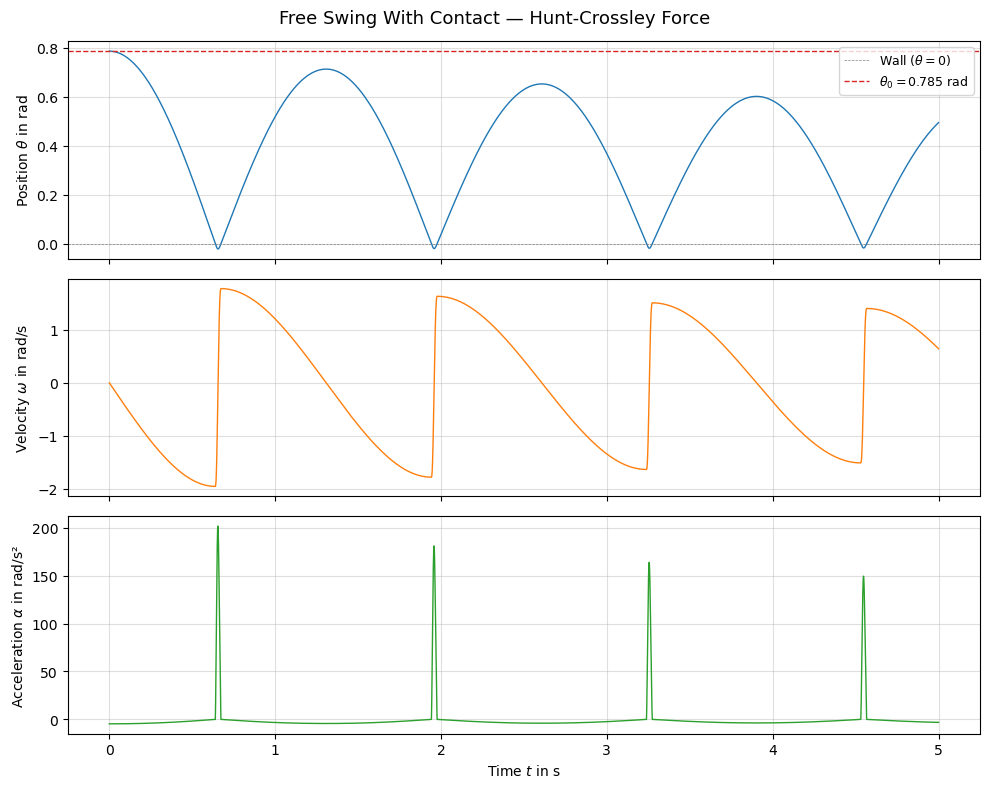

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(res_c['time'], res_c['theta'], linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5, label=r'Wall ($\theta = 0$)')
axes[0].axhline(q0, color='tab:red', linestyle='--', linewidth=1, label=rf'$\theta_0 = {q0:.3f}$ rad')
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].plot(res_c['time'], res_c['omega'], linewidth=1, color='tab:orange')
axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].grid(True, alpha=0.4)

axes[2].plot(res_c['time'], res_c['alpha'], linewidth=1, color='tab:green')
axes[2].set_ylabel(r'Acceleration $\alpha$ in rad/s²')
axes[2].set_xlabel(r'Time $t$ in s')
axes[2].grid(True, alpha=0.4)

fig.suptitle('Free Swing With Contact — Hunt-Crossley Force', fontsize=13)
plt.tight_layout()
plt.show()

The pendulum swings from $\theta_0 = 45°$ toward the wall. Upon impact near $\theta = 0$, the Hunt-Crossley contact force produces a repulsive force that reverses the angular velocity. The dissipation parameter causes energy loss at each collision, so the rebound amplitude decreases over time.

Key observations:
- The **angular velocity** shows a sharp sign change at each wall impact — the pendulum bounces back.
- The **angular acceleration** spikes during contact, reflecting the large contact force.
- The rebound height decreases with each bounce due to energy dissipation.

## With Applied Torque

Now we apply a constant torque that drives the pendulum toward the wall. This creates repeated impacts as the torque pushes the pendulum back into the wall after each rebound.

In [9]:
Mz_drive = -50.0  # torque driving the pendulum toward the wall (negative → toward θ = 0)

model_ct, coord_ct, actuator_ct = build_pendulum_with_contact(default_contact)

res_ct = simulate_contact_pendulum(
    model_ct, coord_ct, actuator_ct,
    torque_func=lambda t: Mz_drive,
    q0=q0, omega0=omega0, dt=dt, t_end=t_end,
)

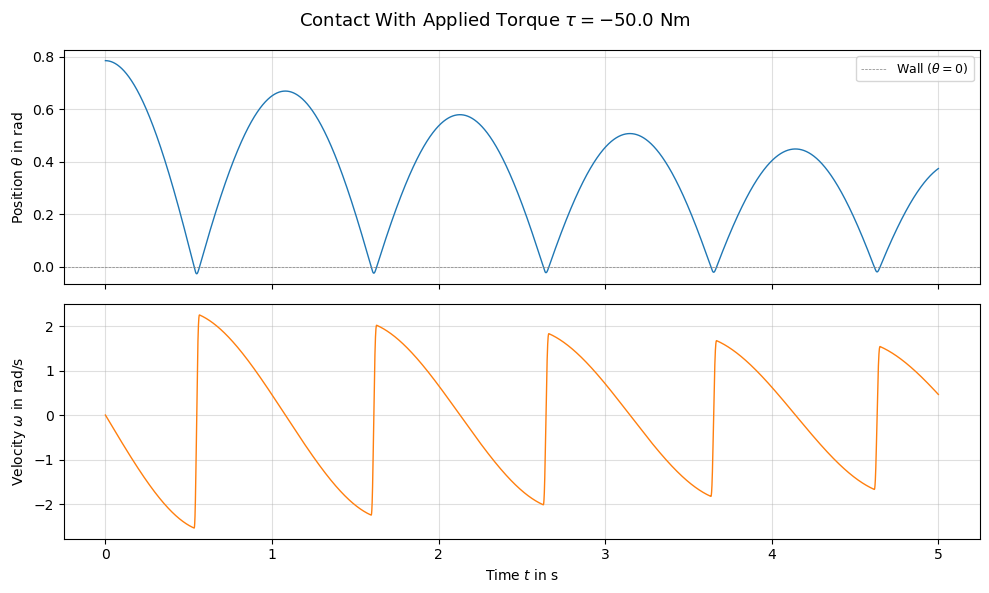

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(res_ct['time'], res_ct['theta'], linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5, label=r'Wall ($\theta = 0$)')
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].plot(res_ct['time'], res_ct['omega'], linewidth=1, color='tab:orange')
axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[1].grid(True, alpha=0.4)

fig.suptitle(rf'Contact With Applied Torque $\tau = {Mz_drive}$ Nm', fontsize=13)
plt.tight_layout()
plt.show()

With the torque driving the pendulum into the wall, we observe repeated impacts. The combination of dissipation and gravity determines whether the pendulum eventually comes to rest against the wall or continues bouncing.

## Parameter Study: Effect of Dissipation

The dissipation coefficient $\alpha$ controls how much energy is lost per collision. We compare three values:

| Config | Dissipation $\alpha$ | Expected behavior |
|--------|---------------------|-------------------|
| Elastic | 0.0 s/m | No energy loss — pendulum rebounds to full height |
| Moderate | 0.5 s/m | Gradual amplitude decay over multiple bounces |
| High | 2.0 s/m | Rapid energy loss — pendulum quickly comes to rest |

We keep the stiffness constant at $k = 10^6$ N/m$^{3/2}$ and disable the applied torque so we can isolate the dissipation effect.

In [11]:
dissipation_values = [0.0, 0.5, 2.0]
dissipation_labels = [f'α = {d} s/m' for d in dissipation_values]

results_diss = {}
for d_val in dissipation_values:
    cp = {
        "stiffness": 1e8,
        "dissipation": d_val,
        "static_friction": 0.0,
        "dynamic_friction": 0.0,
        "viscous_friction": 0.0,
    }
    mdl, crd, act = build_pendulum_with_contact(cp)
    res = simulate_contact_pendulum(
        mdl, crd, act,
        torque_func=lambda t: 0.0,
        q0=q0, omega0=omega0, dt=dt, t_end=t_end,
    )
    results_diss[d_val] = res

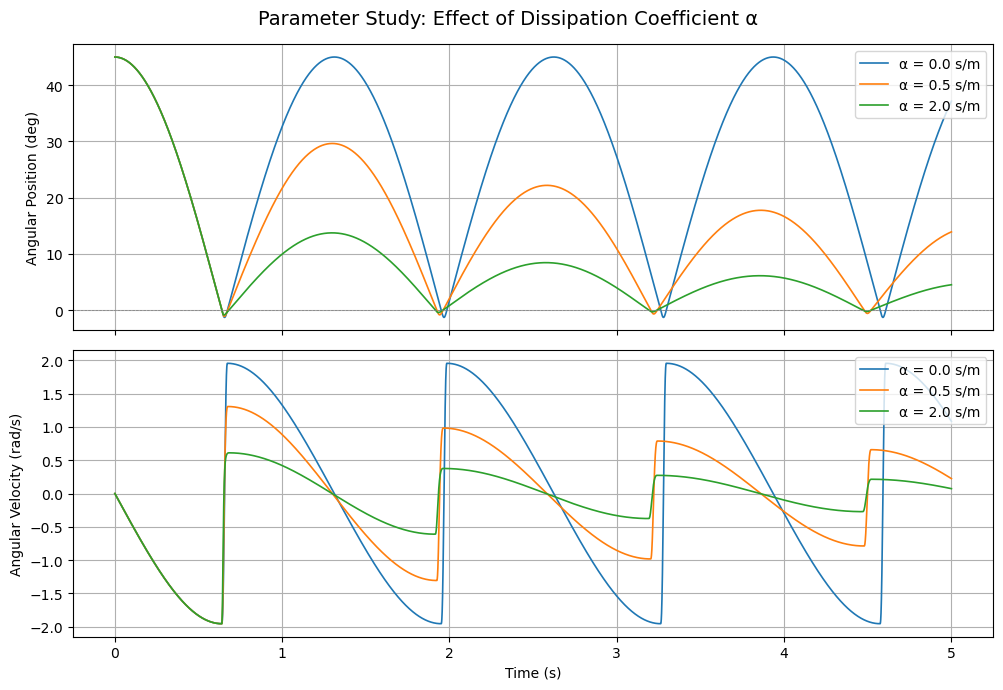

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for d_val, label in zip(dissipation_values, dissipation_labels):
    res = results_diss[d_val]
    axes[0].plot(res['time'], res['theta'], label=label, linewidth=1.2)
    axes[1].plot(res['time'], res['omega'], label=label, linewidth=1.2)

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.4)

fig.suptitle(r'Parameter Study: Effect of Dissipation Coefficient $\alpha$', fontsize=13)
plt.tight_layout()
plt.show()

### Observations — Dissipation

- **Elastic** ($\alpha = 0$): The pendulum rebounds to (nearly) the same height after each wall impact. The total mechanical energy is conserved.
- **Moderate** ($\alpha = 0.5$): Each bounce loses a fraction of kinetic energy. The rebound amplitude decays gradually.
- **High** ($\alpha = 2.0$): Energy is dissipated rapidly. The pendulum may come to rest against the wall after only a few bounces.

This is consistent with the Hunt-Crossley theory: the coefficient of restitution decreases with increasing $\alpha$, following $e \approx 1 - \alpha\,v_i$.

## Parameter Study: Effect of Contact Stiffness

The stiffness $k$ controls how deeply the contact geometries can interpenetrate before the repulsive force becomes significant. We compare three stiffness values with moderate dissipation.

| Config | Stiffness $k$ | Expected behavior |
|--------|--------------|-------------------|
| Soft | $10^{4}$ N/m $^{3/2}$ | Large penetration, smooth force profile, longer contact duration |
| Medium | $10^{6}$ N/m $^{3/2}$ | Moderate penetration |
| Stiff | $10^{8}$ N/m $^{3/2}$ | Near-rigid contact, sharp velocity reversal |

In [12]:
stiffness_values = [1e6, 1e7, 1e9]
stiffness_labels = [f'k = 1e{int(np.log10(s))}' for s in stiffness_values]

results_stiff = {}
for k_val in stiffness_values:
    cp = {
        "stiffness": k_val,
        "dissipation": 0.5,
        "static_friction": 0.0,
        "dynamic_friction": 0.0,
        "viscous_friction": 0.0,
    }
    mdl, crd, act = build_pendulum_with_contact(cp)
    res = simulate_contact_pendulum(
        mdl, crd, act,
        torque_func=lambda t: 0.0,
        q0=q0, omega0=omega0, dt=dt, t_end=t_end,
    )
    results_stiff[k_val] = res

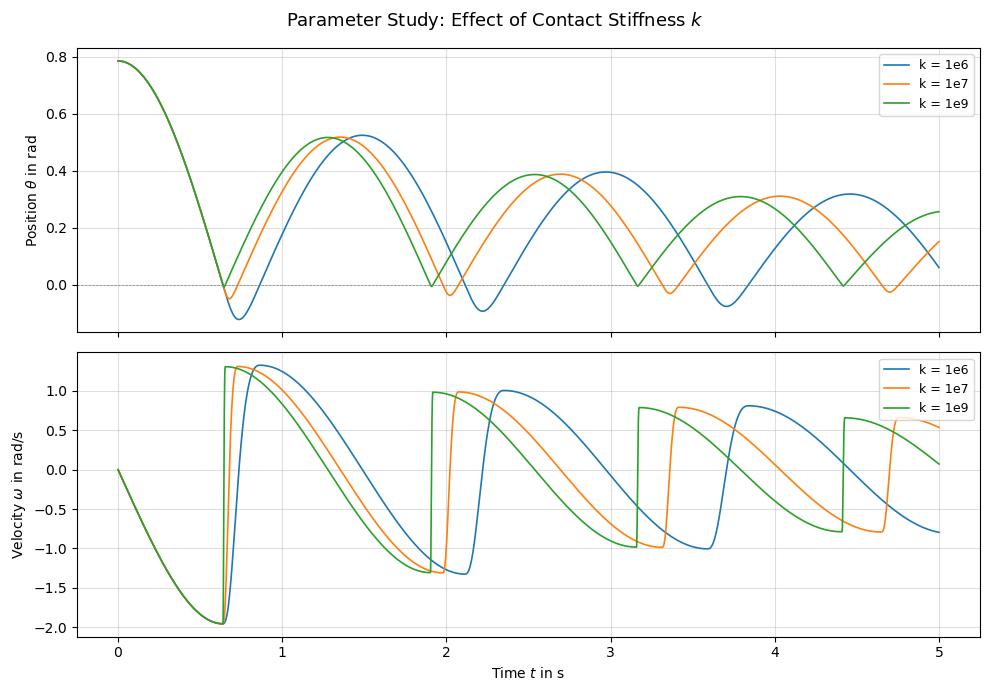

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for k_val, label in zip(stiffness_values, stiffness_labels):
    res = results_stiff[k_val]
    axes[0].plot(res['time'], res['theta'], label=label, linewidth=1.2)
    axes[1].plot(res['time'], res['omega'], label=label, linewidth=1.2)

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.4)

fig.suptitle(r'Parameter Study: Effect of Contact Stiffness $k$', fontsize=13)
plt.tight_layout()
plt.show()

### Observations — Stiffness

- **Soft** ($k = 10^6$): The contact allows significant penetration (the pendulum overshoots past $\theta = 0$). The force ramps up slowly, producing a smoother and longer contact duration. The rebound may appear delayed.
- **Medium** ($k = 10^7$): A good balance — the pendulum bounces crisply with moderate penetration.
- **Stiff** ($k = 10^9$): The contact behaves nearly rigidly. The velocity reversal is almost instantaneous. Very high stiffness can require smaller time steps for numerical stability.

In practice, the stiffness should be chosen to be physically representative of the materials in contact while remaining numerically tractable. Too-soft stiffness produces unrealistic penetration; too-stiff values may require very small integration tolerances.

## Visualize the Motion

We replay the default contact simulation in the OpenSim visualizer.

In [ ]:
import sys
if sys.platform == 'win32':
    states_table = res_c['manager'].getStatesTable()
    visualizer = osim.VisualizerUtilities()
    visualizer.showMotion(res_c['model'], states_table)

## Save Model

In [30]:
model_c.printToXML("pendulum_contact.osim")

True

## Conclusion

In this tutorial we:
- Added `ContactSphere` and `ContactHalfSpace` geometries to model a wall collision.
- Configured a `HuntCrossleyForce` with stiffness and dissipation parameters.
- Simulated the pendulum swinging into a wall, both with and without an applied torque.
- Investigated the effect of the **dissipation coefficient** $\alpha$ on energy loss per collision.
- Investigated the effect of the **contact stiffness** $k$ on penetration depth and collision sharpness.

The Hunt-Crossley model provides a physically motivated contact force that avoids the unphysical artifacts of linear spring-dashpot models. Its two main parameters — stiffness and dissipation — offer intuitive control over the collision behavior.

This completes the OpenSim pendulum tutorial series. The three tutorials together demonstrate the full workflow for building, actuating, and handling contact in an OpenSim rigid-body model.